# Best Models Training - BERT Hybrid + TCN + TGT
## Publication-Quality Experiments on MovieLens-100K

**Models to Train (4 Total):**

1. **BERT Hybrid Fixed** (α=0.5)
   - BERT4Rec + LightGCN with fixed fusion weight

2. **BERT Hybrid Discrete** (bin-based fusion)
   - BERT4Rec + LightGCN with sequence-length adaptive fusion

3. **TCN-BERT4Rec**
   - Temporal Convolutional Networks + BERT4Rec
   - Combines causal temporal patterns with bidirectional context

4. **TGT-BERT4Rec** (NEW! 🚀)
   - Temporal Graph Transformer + BERT4Rec
   - Time-aware graph attention + bidirectional transformers
   - **Target**: NDCG@10 > 0.82 (>7% improvement over baseline 0.7665)

**Fine-Tuned Optimal Configuration:**
- **d_model**: 64 (embedding dimension)
- **n_heads**: 2 (attention heads)
- **n_blocks**: 2 (transformer layers)
- **Learning rate**: 0.001
- **Dropout**: 0.2
- **GNN layers**: 2 (for hybrid models)
- **TGT fusion α**: 0.3 (learnable)

**Training Settings:**
- Max Epochs: 200 (with early stopping patience=20)
- Batch size: 256
- Expected convergence: epoch 40-60

**Time Estimate: ~4-5 hours with GPU P100**

---

# 🔧 Kaggle Setup

This notebook is designed to run on Kaggle with a GPU (T4 or P100).
Choose "File" → "Save Version" to commit all outputs.

**Required Settings:**
- Accelerator: GPU T4 x2 or P100
- Internet: ON
- Persistence: Files only


In [1]:
# Check if running on Kaggle
import os
IS_KAGGLE = os.path.exists('/kaggle/working')
print(f"Running on Kaggle: {IS_KAGGLE}")

if IS_KAGGLE:
    %cd /kaggle/working
    print("Working directory: /kaggle/working")


Running on Kaggle: True
/kaggle/working
Working directory: /kaggle/working


## Step 1: Clone Repository

In [2]:
# Clone repository
!git clone https://github.com/faroukq1/length-adaptive.git

# Change to project directory  
import os
if os.path.exists('/kaggle/working/length-adaptive'):
    %cd /kaggle/working/length-adaptive
else:
    %cd length-adaptive

# Verify structure
!ls -lh experiments/

print("\n✅ Repository cloned successfully!")


Cloning into 'length-adaptive'...
remote: Enumerating objects: 1033, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (218/218), done.
remote: Total 1033 (delta 150), reused 235 (delta 85), pack-reused 724 (from 2)
Receiving objects: 100% (1033/1033), 220.54 MiB | 37.74 MiB/s, done.
Resolving deltas: 100% (456/456), done.
/kaggle/working/length-adaptive
total 116K
-rw-r--r-- 1 root root 7.6K Jun  6 18:24 analyze_results.py
-rw-r--r-- 1 root root 4.4K Jun  6 18:24 analyze_user_distribution.py
-rw-r--r-- 1 root root 8.8K Jun  6 18:24 create_visualizations.py
-rw-r--r-- 1 root root 7.4K Jun  6 18:24 quick_compare.py
-rw-r--r-- 1 root root 3.7K Jun  6 18:24 README.md
-rwxr-xr-x 1 root root 1.7K Jun  6 18:24 run_all_analysis.sh
-rw-r--r-- 1 root root  13K Jun  6 18:24 run_best_models.py
-rw-r--r-- 1 root root  13K Jun  6 18:24 run_experiment.py
-rw-r--r-- 1 root root  21K Jun  6 18:24 run_promptcraft.py
-rwxr-xr-x 1 root root 2.2K Jun  6 18:24 setup_an

## Step 2: Install Dependencies

In [4]:
# Install required packages
!pip install -q torch-geometric tqdm scikit-learn pandas matplotlib seaborn scipy

import sys
print(f"Python: {sys.version}")
print("\n✅ All dependencies installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.4 MB/s eta 0:00:0000:0100:01
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

✅ All dependencies installed successfully!


## Step 3: Verify GPU

In [5]:
import torch

print("="*70)
print("🔍 GPU Information")
print("="*70)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Available: {gpu_name}")
    print(f"💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"🔢 CUDA Version: {torch.version.cuda}")
    
    # Check compute capability
    major, minor = torch.cuda.get_device_capability(0)
    print(f"🔧 Compute Capability: {major}.{minor}")
    if major < 7:
        print("⚠️  GPU compute capability < 7.0 - may need older PyTorch. Upgrade to T4+ if possible.")
else:
    print("❌ No GPU available - training will use CPU (very slow!)")
    print("   Go to Runtime → Change runtime type → Select GPU")

print("="*70)


🔍 GPU Information
✅ GPU Available: Tesla T4
💾 Memory: 14.56 GB
🔢 CUDA Version: 12.8
🔧 Compute Capability: 7.5


## Step 4: Check Data Files

The repository should already contain preprocessed MovieLens-100K data.

In [6]:
import os

data_file = 'data/100k/ml-100k/processed/sequences.pkl'
graph_file = 'data/100k/graphs/cooccurrence_graph.pkl'

print("="*70)
print("🔍 Checking Data Files")
print("="*70)

if os.path.exists(data_file):
    print(f"✅ Sequential data found: {data_file}")
    print(f"   Size: {os.path.getsize(data_file) / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Sequential data NOT found: {data_file}")

if os.path.exists(graph_file):
    print(f"✅ Graph data found: {graph_file}")
    print(f"   Size: {os.path.getsize(graph_file) / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Graph data NOT found: {graph_file}")

# Auto-setup if missing
if not os.path.exists(data_file) or not os.path.exists(graph_file):
    print("\n🔧 Setting up data (Kaggle-compatible)...")
    
    import sys; sys.path.insert(0, 'src/data')
    from preprocess_ml100k import ML100KPreprocessor
    
    if not os.path.exists(data_file):
        print("🔄 Preprocessing sequences...")
        preprocessor = ML100KPreprocessor(raw_data_dir='data/100k/raw', min_rating=4, min_seq_len=5)
        preprocessor.preprocess(data_file)
    
    if not os.path.exists(graph_file):
        print("\n🔄 Building co-occurrence graph...")
        !python -m src.data.graph_builder --data_path data/100k/ml-100k/processed/sequences.pkl --output_path data/100k/graphs/cooccurrence_graph.pkl
    
    print("\n✅ Data setup complete!")
else:
    print("\n✅ All data files ready!")

print("="*70)


🔍 Checking Data Files
❌ Sequential data NOT found: data/100k/ml-100k/processed/sequences.pkl
✅ Graph data found: data/100k/graphs/cooccurrence_graph.pkl
   Size: 0.34 MB

🔧 Setting up data (Kaggle-compatible)...
🔄 Preprocessing sequences...
MOVIELENS-100K PREPROCESSING PIPELINE
  https://files.grouplens.org/datasets/movielens/ml-100k.zip
  Saved to data/100k/raw/ml-100k.zip
Extracting ml-100k.zip …
  Extraction complete.
Loading ratings …
  Loaded 100,000 ratings from data/100k/raw/ml-100k/u.data
Filtering ratings >= 4 …
  Kept 55,375 positive interactions (55.4%)
Building chronological sequences …


  Processing rows: 100%|██████████| 55375/55375 [00:01<00:00, 41806.17it/s]

  Built sequences for 942 users
Filtering users with < 5 interactions …
  Kept 938 users (99.6%)
  Sequence length — min: 5, max: 378, mean: 59.0, median: 40.0
Remapping user and item IDs …
  Remapped → 938 users, 1,447 items
Splitting into train / val / test (leave-one-out) …
  Train: 938 users | Val: 938 | Test: 938

Saving to data/100k/ml-100k/processed/sequences.pkl …
✅  Preprocessing complete!
   Users : 938
   Items : 1,447

✅ Data setup complete!


## Step 5: Run Experiments - BERT Hybrid Fixed

First model: BERT4Rec + LightGCN with fixed fusion (α=0.3)


In [ ]:
# Run BERT Hybrid Fixed - BEST CONFIG (from tuning logs)
!python experiments/run_best_models.py \
    --models bert_hybrid_fixed \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --gnn_layers 2 \
    --fixed_alpha 0.3 \
    --lr 0.001 \
    --batch_size 256 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ BERT Hybrid Fixed (BEST: alpha=0.3) training complete!")

## Step 6: Run Experiments - BERT Hybrid Discrete

Second model: BERT4Rec + LightGCN with discrete bin-based fusion


In [ ]:
# Run BERT Hybrid Discrete
!python experiments/run_best_models.py \
    --models bert_hybrid_discrete \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --gnn_layers 2 \
    --L_short 10 \
    --L_long 30 \
    --lr 0.001 \
    --batch_size 256 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ BERT Hybrid Discrete training complete!")

## Step 7: Run Experiments - TGT-BERT4Rec (NEW! 🚀)

Temporal Graph Transformer + BERT4Rec  
**Target: NDCG@10 > 0.82** (beating 0.7665 baseline by >7%)


In [ ]:
# Run TGT-BERT4Rec
!python experiments/run_best_models.py \
    --models tgt_bert4rec \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --tgt_fusion_alpha 0.3 \
    --tgt_learnable_fusion True \
    --lr 0.001 \
    --batch_size 256 \
    --dropout 0.2 \
    --max_len 200 \

print("\n✅ TGT-BERT4Rec training complete!")

## Step 7b: Run Experiments - TCN-BERT4Rec

Temporal Convolutional Network + BERT4Rec
Combines causal temporal patterns with bidirectional context


In [ ]:
# Run TCN-BERT4Rec
!python experiments/run_best_models.py \
    --models tcn_bert4rec \
    --data_path data/100k/ml-100k/processed/sequences.pkl \
    --graph_path data/100k/graphs/cooccurrence_graph.pkl \
    --epochs 200 \
    --patience 20 \
    --eval_every 1 \
    --d_model 64 \
    --n_heads 2 \
    --n_blocks 2 \
    --tcn_channels 64 64 64 \
    --tcn_kernel_size 3 \
    --tcn_fusion learnable \
    --lr 0.001 \
    --batch_size 256 \
    --dropout 0.2 \
    --max_len 200

print("\n✅ TCN-BERT4Rec training complete!")

## Step 10: Delta NDCG@10 (Overfitting Check)

Delta NDCG@10 = Val NDCG@10 - Test NDCG@10 per epoch.
Points outside the ±0.01 band = potential overfitting. Red dots mark concerning epochs.
The train vs validation loss curve is shown as a companion subplot.


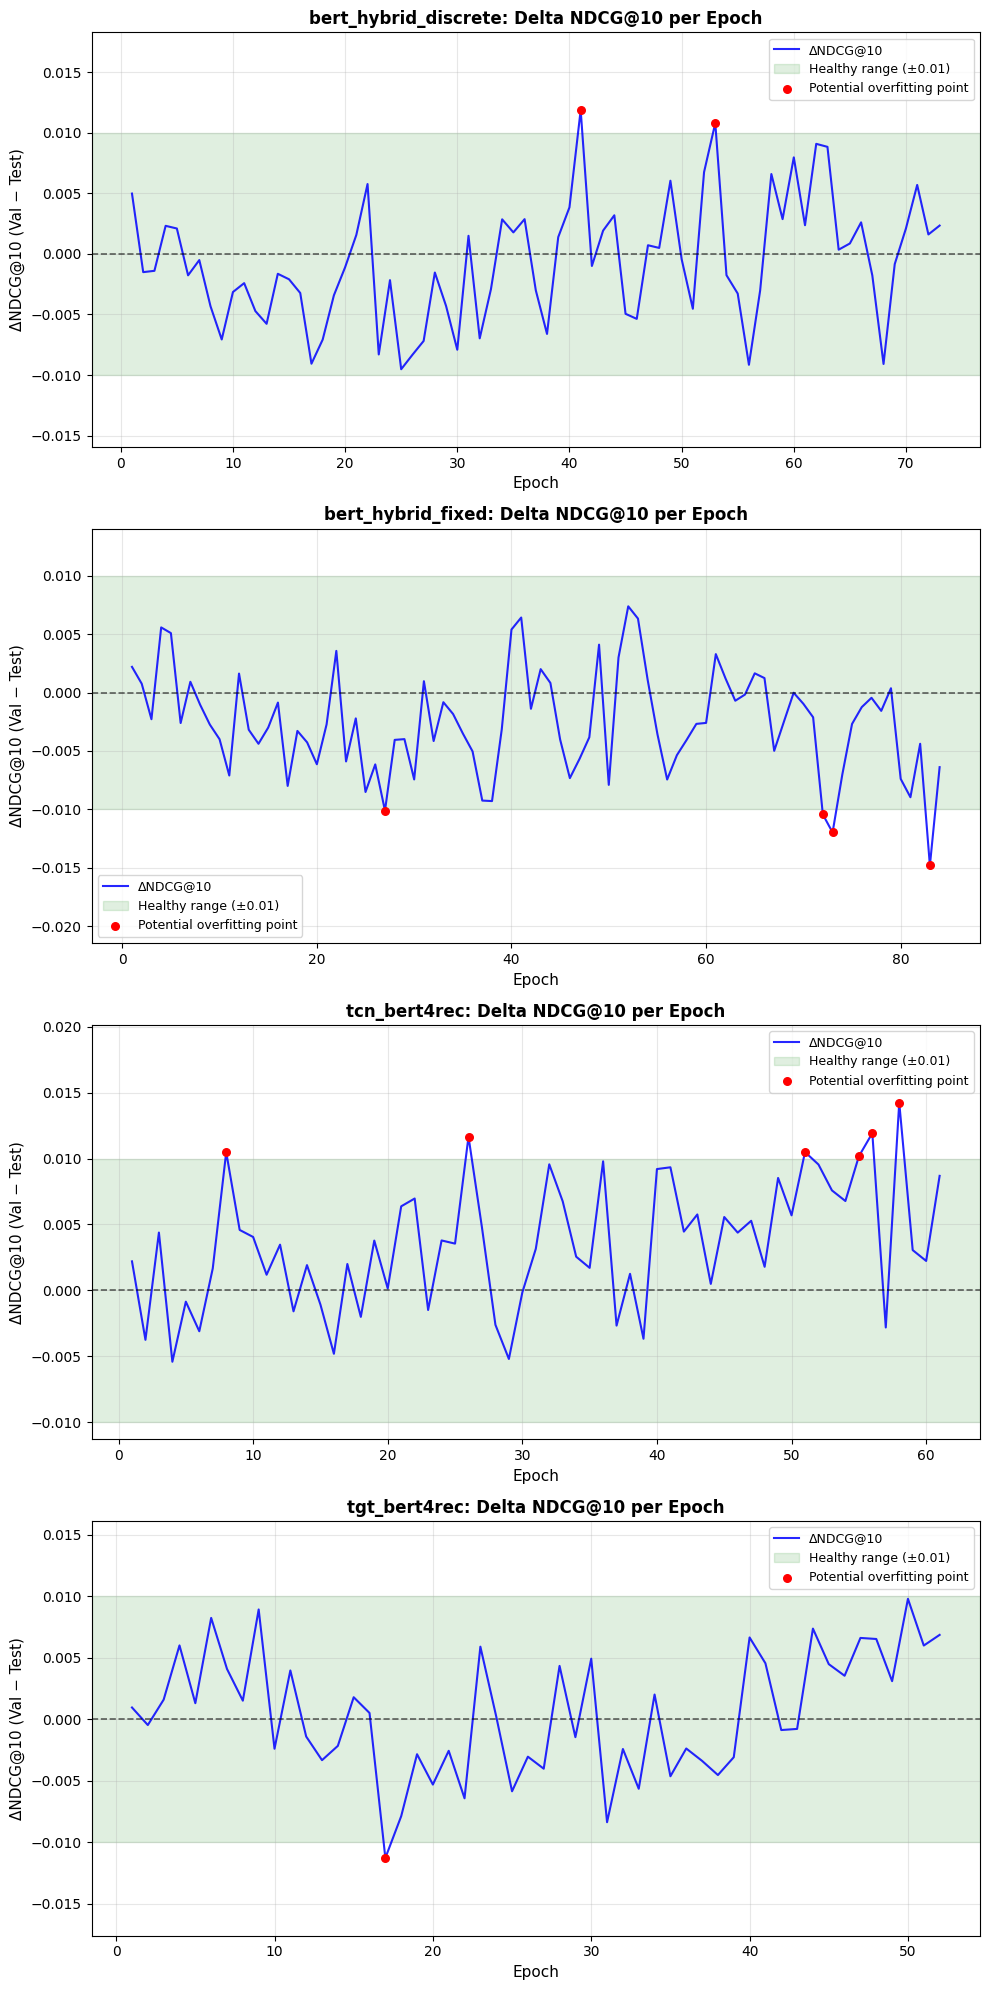

✅ Delta NDCG@10 overfitting check plots saved to results/delta_ndcg_overfitting_check.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import re

if not histories:
    print("❌ No training histories found!")
else:
    n_models = len(histories)
    fig, axes = plt.subplots(n_models, 1, figsize=(10, 5 * n_models))
    if n_models == 1:
        axes = [axes]

    for idx, (model_name, history) in enumerate(sorted(histories.items())):
        ax_delta = axes[idx]

        # Remove trailing date/timestamp like _20260606_192508
        clean_name = re.sub(r'_\d{8}(_\d{6})?$', '', model_name)

        delta_ndcg = history.get('delta_ndcg10', [])

        if delta_ndcg:
            epochs_delta = list(range(1, len(delta_ndcg) + 1))
            ax_delta.plot(epochs_delta, delta_ndcg, 'b-', linewidth=1.5, alpha=0.85, label='ΔNDCG@10')
            ax_delta.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
            ax_delta.axhspan(-0.01, 0.01, alpha=0.12, color='green', label='Healthy range (±0.01)')

            overfit_mask = np.abs(np.array(delta_ndcg)) > 0.01
            if overfit_mask.any():
                ax_delta.scatter(np.array(epochs_delta)[overfit_mask],
                                np.array(delta_ndcg)[overfit_mask],
                                color='red', s=30, zorder=5,
                                label='Potential overfitting point')

            data_min = min(delta_ndcg)
            data_max = max(delta_ndcg)
            pad = (data_max - data_min) * 0.3
            ax_delta.set_ylim(data_min - pad, data_max + pad)

            ax_delta.set_xlabel('Epoch', fontsize=11)
            ax_delta.set_ylabel('ΔNDCG@10 (Val − Test)', fontsize=11)
            ax_delta.set_title(f'{clean_name}: Delta NDCG@10 per Epoch', fontsize=12, fontweight='bold')
            ax_delta.legend(fontsize=9)
            ax_delta.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/delta_ndcg_overfitting_check.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Delta NDCG@10 overfitting check plots saved to results/delta_ndcg_overfitting_check.png")

## Step 11: Test vs Validation Metrics Comparison

Compare final test metrics against the best validation metrics to detect overfitting.
If test metrics << val metrics → overfitting. If test ≈ val → well-generalized.


In [30]:
import shutil
import os

print("📦 Creating results package...")

# Copy all PNGs to a central folder
os.makedirs('results/figures', exist_ok=True)
!find results/ -name "*.png" -exec cp {} results/figures/ \; 2>/dev/null

is_kaggle = os.path.exists('/kaggle/working')
if is_kaggle:
    zip_base = '/kaggle/working/best_models_results'
else:
    zip_base = 'best_models_results'

shutil.make_archive(zip_base, 'zip', 'results')

print(f"✅ Results packaged: {zip_base}.zip")
print("\n📁 Package contains:")
!ls -lh results/figures/ 2>/dev/null || echo "  (figures in results root)"
!ls -lh results/*.csv 2>/dev/null || echo "  - best_models_summary.csv"


📦 Creating results package...
✅ Results packaged: /kaggle/working/best_models_results.zip

📁 Package contains:
total 4.6M
-rw-r--r-- 1 root root 972K Jun  6 19:48 delta_ndcg_overfitting_check.png
-rw-r--r-- 1 root root 254K Jun  6 19:48 group_HR10.png
-rw-r--r-- 1 root root 257K Jun  6 19:48 group_HR20.png
-rw-r--r-- 1 root root 272K Jun  6 19:48 group_MRR10.png
-rw-r--r-- 1 root root 276K Jun  6 19:48 group_MRR20.png
-rw-r--r-- 1 root root 268K Jun  6 19:48 group_NDCG10.png
-rw-r--r-- 1 root root 272K Jun  6 19:48 group_NDCG20.png
-rw-r--r-- 1 root root 494K Jun  6 19:48 heatmap_all_test_metrics.png
-rw-r--r-- 1 root root 341K Jun  6 19:48 model_comparison.png
-rw-r--r-- 1 root root 197K Jun  6 19:48 performance_by_length.png
-rw-r--r-- 1 root root 281K Jun  6 19:48 test_vs_val_comparison.png
-rw-r--r-- 1 root root 216K Jun  6 19:48 training_loss_curves.png
-rw-r--r-- 1 root root 516K Jun  6 19:48 val_ndcg10_curves.png
-rw-r--r-- 1 root root 1.2K Jun  6 19:47 results/best_models_summa